In [1]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, make_scorer, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from scipy.special import softmax
from sklearn.utils.class_weight import compute_sample_weight
from scipy.special import expit


In [2]:
data = pd.read_parquet("data/full_dataset_v2.parquet")

In [3]:
# Fill missing data with average reading across stations at given time
variables = ['RH', 'DR', 'SQ', 'Q', 'temp', 'TD', 'FF', 'FH', 'P', 'N', 'VV','DD', 
             'rh', 'T10N', 'FX', 'WW', 'IX', 'M', 'R', 'S', 'O', 'Y', 'BC', 'CO', 
             'H2S', 'NH3', 'NOx', 'O3', 'Ox', 'SO2', 'no2', 'pm10', 'pm25']

for var in variables:
    data[var] = data.groupby("date")[var].transform(lambda x: x.fillna(x.mean()))

In [4]:
summary_stats = pd.DataFrame({
    "data count": data.count(),
    "missing values": data.isnull().sum(),
    "percentage missing": (data.isnull().sum() / len(data)) * 100})

summary_stats.to_latex("data/missing_data_stats_2.tex", index=True)

In [5]:
summary_stats

,data count,missing values,percentage missing
date,65413,0,0.000000
RH,65413,0,0.000000
DR,65413,0,0.000000
SQ,65413,0,0.000000
Q,65413,0,0.000000
temp,65413,0,0.000000
TD,65413,0,0.000000
FF,65397,16,0.024460
FH,65397,16,0.024460
P,65051,362,0.553407


In [6]:
# Fill in remaining missing values with mean of each feature
data[variables] = data[variables].fillna(data[variables].mean())

In [7]:
# Prepare variables for modeling
# Variables division (excluding ZWR due to 0 records)
meteorological_features = ['Q', 'temp', 'TD', 'FF', 'FH', 'P','DD', 'T10N', 'FX', "rh"]
all_features = ['Q', 'temp', 'TD', 'FF', 'FH', 'P','DD', 'T10N', 'FX', 'BC', 'CO', 
             'H2S', 'NH3', 'NOx', 'O3', 'Ox', 'SO2', 'no2', 'pm10', 'pm25', "rh"]


In [8]:
data["category_int"] = data["precipitation_category"].map({"Low": 0, "Lower-Moderate": 1, "Moderate": 2, "Higher-Moderate": 3, "High": 4})


In [9]:
Y = data["category_int"]
X = data[all_features]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y) # check if i need to stratify

# Setting max iterations for SVM to prevent long training times
iterations = 10000


In [10]:
# List to store results
results = []

#### Meteorological data split and scaling

In [11]:
scaler = StandardScaler()

X_train_meteorological = X_train[meteorological_features]
X_test_meteorological = X_test[meteorological_features]

X_train_meteorological = scaler.fit_transform(X_train_meteorological)
X_test_meteorological = scaler.transform(X_test_meteorological)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#### Meteorological only

#### XGBoost

In [12]:
recall_class4 = make_scorer(
    recall_score,
    labels=[4],
    average="micro"
)

weight_strategies = {
    "none": None,
    "balanced": "balanced",
    "balanced_x2_class4": "balanced_x2_class4"
}

def make_weights(strategy, y):
    base = compute_sample_weight("balanced", y)

    if strategy == "none":
        return np.ones_like(y, dtype=float)

    if strategy == "balanced":
        return base

    if strategy == "balanced_x2_class4":
        return np.where(y == 4, base * 2.0, base)

In [13]:
f1_macro_scorer = make_scorer(f1_score, average="macro")

scoring = {
    "recall_class4": recall_class4,
    "f1_macro": f1_macro_scorer
}

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

best_models_met_xgb = []

for name in weight_strategies:

    print(f"Training with weighting strategy: {name}")

    weights = make_weights(name, y_train)

    model = XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    )

    grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    refit="recall_class4",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

    grid_search.fit(
        X_train_meteorological,
        y_train,
        sample_weight=weights
    )

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    xgboost_predictions_met = best_model.predict(X_test_meteorological)

    recall4 = recall_score(y_test, xgboost_predictions_met, labels=[4], average="micro")
    recall4_train = recall_score(y_train, best_model.predict(X_train_meteorological), labels=[4], average="micro")
    macrof1 = classification_report(y_test, xgboost_predictions_met, output_dict=True)["macro avg"]["f1-score"]
    recall = recall_score(y_test, xgboost_predictions_met, average="macro")
    precision = classification_report(y_test, xgboost_predictions_met, output_dict=True)["macro avg"]["precision"]

    best_models_met_xgb.append((name, best_model, best_params, recall4, recall4_train, macrof1, recall, precision, weights))

Training with weighting strategy: none
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Training with weighting strategy: balanced
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Training with weighting strategy: balanced_x2_class4
Fitting 3 folds for each of 12 candidates, totalling 36 fits


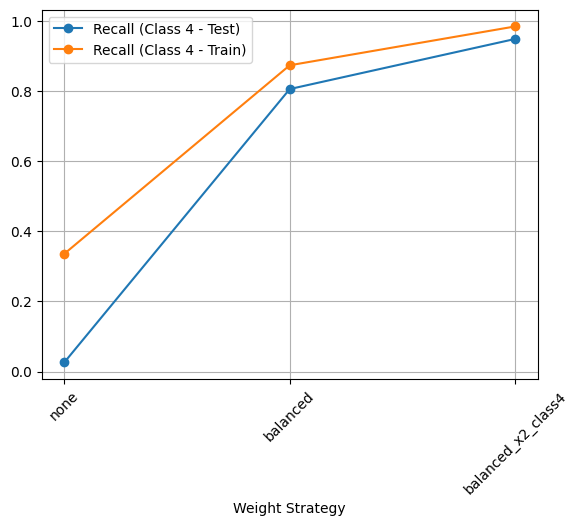

In [14]:
df_met_xgb = pd.DataFrame(best_models_met_xgb, columns=["weighting", "model", "best_params", "recall_class4", "recall_class4_train", "macro_f1", "recall", "precision", "weights"])

plt.plot(df_met_xgb["weighting"], df_met_xgb["recall_class4"], marker="o", label="Recall (Class 4 - Test)")
plt.plot(df_met_xgb["weighting"], df_met_xgb["recall_class4_train"], marker="o", label="Recall (Class 4 - Train)")
  
plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

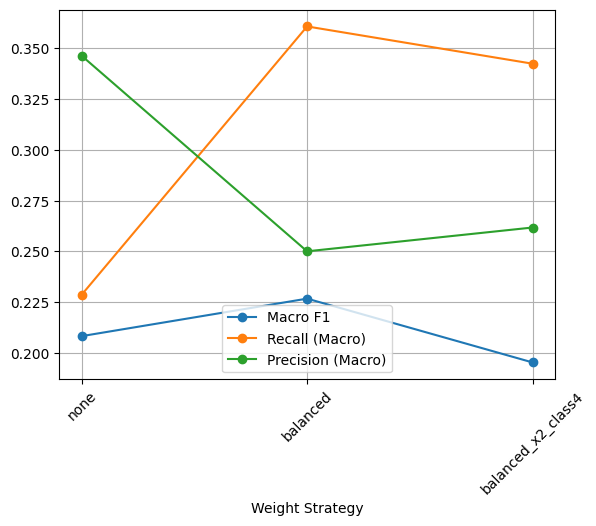

In [15]:
plt.plot(df_met_xgb["weighting"], df_met_xgb["macro_f1"], marker="o", label="Macro F1")
plt.plot(df_met_xgb["weighting"], df_met_xgb["recall"], marker="o", label="Recall (Macro)")
plt.plot(df_met_xgb["weighting"], df_met_xgb["precision"], marker="o", label="Precision (Macro)")  

plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

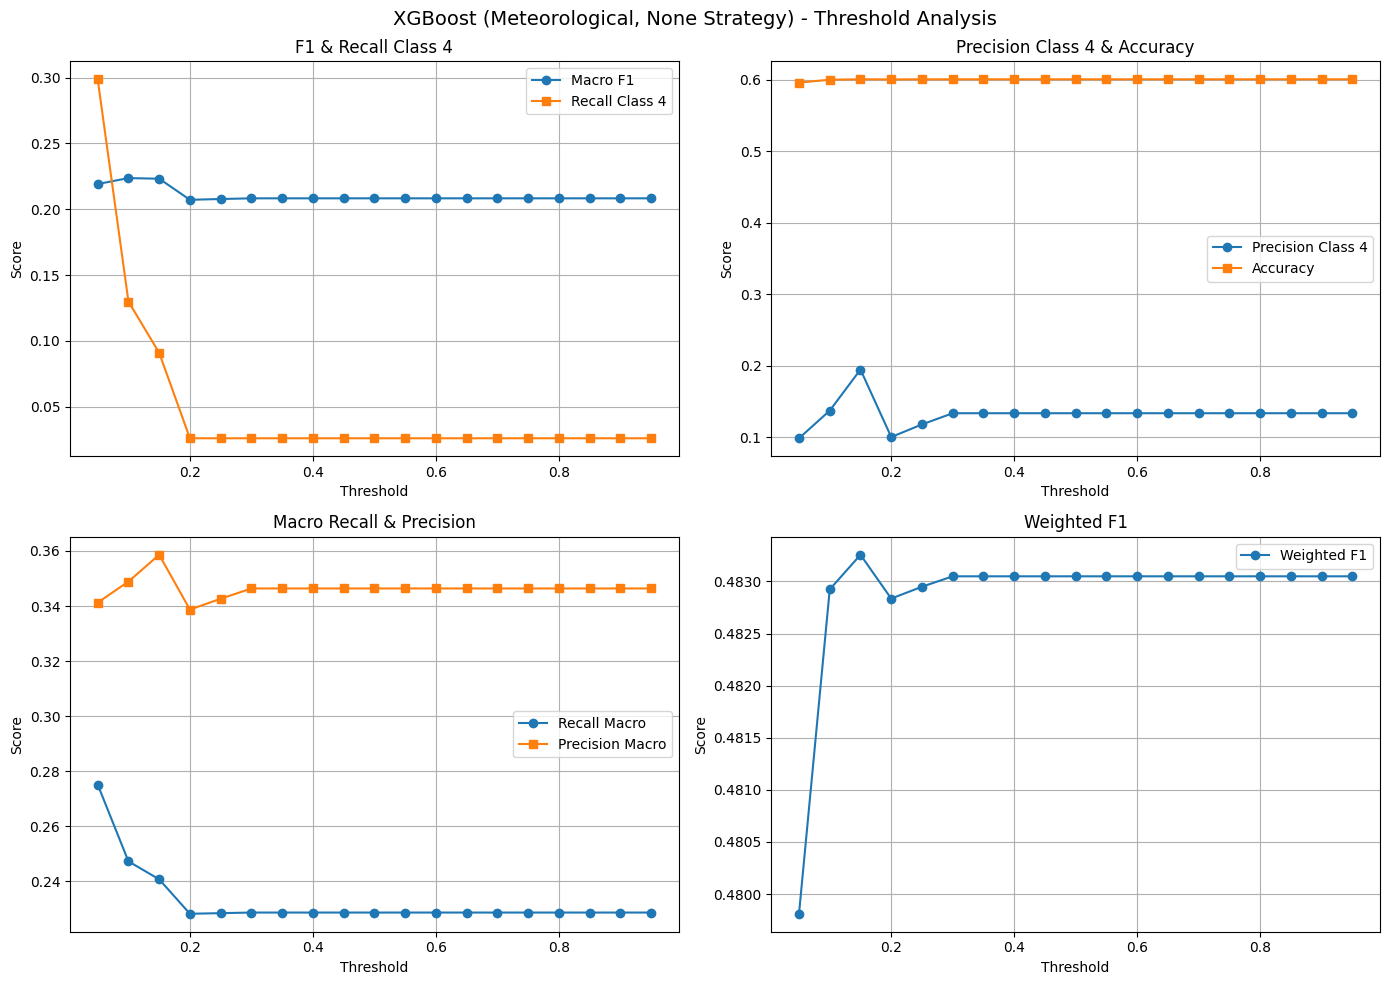

In [16]:
# Threshold analysis for XGBoost Meteorological (none strategy)
def threshold_analysis_multiclass(y_true, y_proba, thresholds=None):
    """Analyze metrics across different thresholds for class 4 (High precipitation)."""
    if thresholds is None:
        thresholds = np.arange(0.05, 1.0, 0.05)
    
    results_threshold = []
    for threshold in thresholds:
        class_4_proba = y_proba[:, 4]
        preds = np.argmax(y_proba, axis=1)
        preds = np.where(class_4_proba >= threshold, 4, preds)
        
        from sklearn.metrics import precision_score
        f1_macro = f1_score(y_true, preds, average="macro")
        f1_weighted = f1_score(y_true, preds, average="weighted")
        recall_4 = recall_score(y_true, preds, labels=[4], average="micro")
        precision_4 = precision_score(y_true, preds, labels=[4], average="micro")
        recall_macro = recall_score(y_true, preds, average="macro")
        precision_macro = precision_score(y_true, preds, average="macro")
        accuracy = accuracy_score(y_true, preds)
        
        results_threshold.append({
            "threshold": threshold,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "recall_class4": recall_4,
            "precision_class4": precision_4,
            "recall_macro": recall_macro,
            "precision_macro": precision_macro,
            "accuracy": accuracy
        })
    
    return pd.DataFrame(results_threshold)

xgb_met_none = next(m for m in best_models_met_xgb if m[0] == "none")
xgb_met_proba = xgb_met_none[1].predict_proba(X_test_meteorological)
xgb_met_threshold = threshold_analysis_multiclass(y_test, xgb_met_proba, np.arange(0.05, 1.0, 0.05))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("XGBoost (Meteorological, None Strategy) - Threshold Analysis", fontsize=14)

axes[0, 0].plot(xgb_met_threshold["threshold"], xgb_met_threshold["f1_macro"], marker="o", label="Macro F1")
axes[0, 0].plot(xgb_met_threshold["threshold"], xgb_met_threshold["recall_class4"], marker="s", label="Recall Class 4")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 0].set_title("F1 & Recall Class 4")

axes[0, 1].plot(xgb_met_threshold["threshold"], xgb_met_threshold["precision_class4"], marker="o", label="Precision Class 4")
axes[0, 1].plot(xgb_met_threshold["threshold"], xgb_met_threshold["accuracy"], marker="s", label="Accuracy")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].set_title("Precision Class 4 & Accuracy")

axes[1, 0].plot(xgb_met_threshold["threshold"], xgb_met_threshold["recall_macro"], marker="o", label="Recall Macro")
axes[1, 0].plot(xgb_met_threshold["threshold"], xgb_met_threshold["precision_macro"], marker="s", label="Precision Macro")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_title("Macro Recall & Precision")

axes[1, 1].plot(xgb_met_threshold["threshold"], xgb_met_threshold["f1_weighted"], marker="o", label="Weighted F1")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_title("Weighted F1")

plt.tight_layout()
plt.show()

In [17]:
# Override best threshold as requested
best_threshold_xgb_met = 0.15
print(f"XGBoost (Meteorological, None): Best threshold for Macro F1 set to {best_threshold_xgb_met:.3f}")

# Make predictions using best threshold
class_4_proba = xgb_met_proba[:, 4]
xgb_met_preds_threshold = np.argmax(xgb_met_proba, axis=1)
xgb_met_preds_threshold = np.where(class_4_proba >= best_threshold_xgb_met, 4, xgb_met_preds_threshold)

classification_report_xgboost_met_weights = classification_report(
    y_test,
    xgb_met_preds_threshold,
    output_dict=True
)

XGBoost (Meteorological, None): Best threshold for Macro F1 set to 0.150


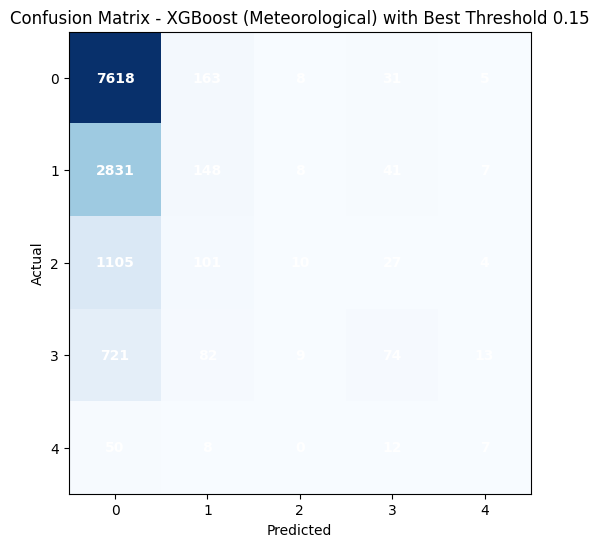

In [18]:
confusion_matrix_xgboost_met_weights = confusion_matrix(y_test, xgb_met_preds_threshold)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_xgboost_met_weights, interpolation="nearest", cmap=plt.cm.Blues)

for i in range(confusion_matrix_xgboost_met_weights.shape[0]):
    for j in range(confusion_matrix_xgboost_met_weights.shape[1]):
        plt.text(j, i, str(confusion_matrix_xgboost_met_weights[i, j]),
                ha="center", va="center", color="white", fontweight="bold")

plt.title(f"Confusion Matrix - XGBoost (Meteorological) with Best Threshold {best_threshold_xgb_met:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
results.append({
    "model": "XGBoost",
    "features": "Meteorological",

    "precision_class_4": classification_report_xgboost_met_weights["4"]["precision"],
    "precision_class_3": classification_report_xgboost_met_weights["3"]["precision"],
    "precision_class_2": classification_report_xgboost_met_weights["2"]["precision"],
    "precision_class_1": classification_report_xgboost_met_weights["1"]["precision"],
    "precision_class_0": classification_report_xgboost_met_weights["0"]["precision"],
    "recall_class_4": classification_report_xgboost_met_weights["4"]["recall"],
    "recall_class_3": classification_report_xgboost_met_weights["3"]["recall"],
    "recall_class_2": classification_report_xgboost_met_weights["2"]["recall"],
    "recall_class_1": classification_report_xgboost_met_weights["1"]["recall"],
    "recall_class_0": classification_report_xgboost_met_weights["0"]["recall"],
    "f1_class_4": classification_report_xgboost_met_weights["4"]["f1-score"],
    "f1_class_3": classification_report_xgboost_met_weights["3"]["f1-score"],
    "f1_class_2": classification_report_xgboost_met_weights["2"]["f1-score"],
    "f1_class_1": classification_report_xgboost_met_weights["1"]["f1-score"],
    "f1_class_0": classification_report_xgboost_met_weights["0"]["f1-score"],
    "support_class_4": classification_report_xgboost_met_weights["4"]["support"],
    "support_class_3": classification_report_xgboost_met_weights["3"]["support"],
    "support_class_2": classification_report_xgboost_met_weights["2"]["support"],
    "support_class_1": classification_report_xgboost_met_weights["1"]["support"],
    "support_class_0": classification_report_xgboost_met_weights["0"]["support"],

    "macro_f1": classification_report_xgboost_met_weights["macro avg"]["f1-score"],
    "weighted_f1": classification_report_xgboost_met_weights["weighted avg"]["f1-score"],
    "precision_macro": classification_report_xgboost_met_weights["macro avg"]["precision"],
    "recall_macro": classification_report_xgboost_met_weights["macro avg"]["recall"],
    "best_threshold": best_threshold_xgb_met,
    "best params": xgb_met_none[2]  
})

#### SVM

In [20]:
best_models_met_svm = []

for name in ["none"]:

    svm_model_met = SVC(
    kernel='rbf',
    max_iter=iterations,
    random_state=42
    )

    param_grid = {
    "C": [1, 10],
    "gamma": ["scale", 0.01]
    }

    weights = make_weights(name, y_train)

    grid_search = GridSearchCV(
        estimator=svm_model_met,
        param_grid=param_grid,
        scoring=recall_class4,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid_search.fit(
        X_train_meteorological,
        y_train,
        **{"sample_weight": weights}
    )

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    preds = best_model.predict(X_test_meteorological)


    recall4 = recall_score(y_test, preds, labels=[4], average="micro")
    recall4_train = recall_score(y_train, best_model.predict(X_train_meteorological), labels=[4], average="micro")
    macrof1 = classification_report(y_test, preds, output_dict=True)["macro avg"]["f1-score"]
    recall = recall_score(y_test, preds, average="macro")
    precision = classification_report(y_test, preds, output_dict=True)["macro avg"]["precision"]

    best_models_met_svm.append((name, best_model, best_params, recall4, recall4_train, macrof1, recall, precision, weights))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\majak\Desktop\Uni\Thesis\Extreme-precipitation\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


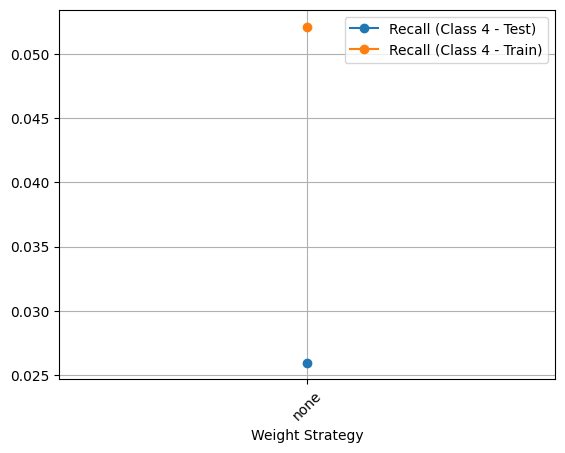

In [21]:
df_met_svm = pd.DataFrame(best_models_met_svm, columns=["weighting", "model", "best_params", "recall_class4", "recall_class4_train", "macro_f1", "recall", "precision", "weights"])

plt.plot(df_met_svm["weighting"], df_met_svm["recall_class4"], marker="o", label="Recall (Class 4 - Test)")
plt.plot(df_met_svm["weighting"], df_met_svm["recall_class4_train"], marker="o", label="Recall (Class 4 - Train)")
  
plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

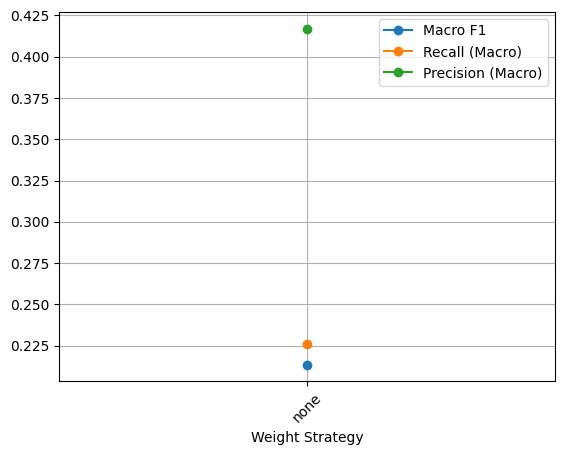

In [22]:
plt.plot(df_met_svm["weighting"], df_met_svm["macro_f1"], marker="o", label="Macro F1")
plt.plot(df_met_svm["weighting"], df_met_svm["recall"], marker="o", label="Recall (Macro)")
plt.plot(df_met_svm["weighting"], df_met_svm["precision"], marker="o", label="Precision (Macro)")  

plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

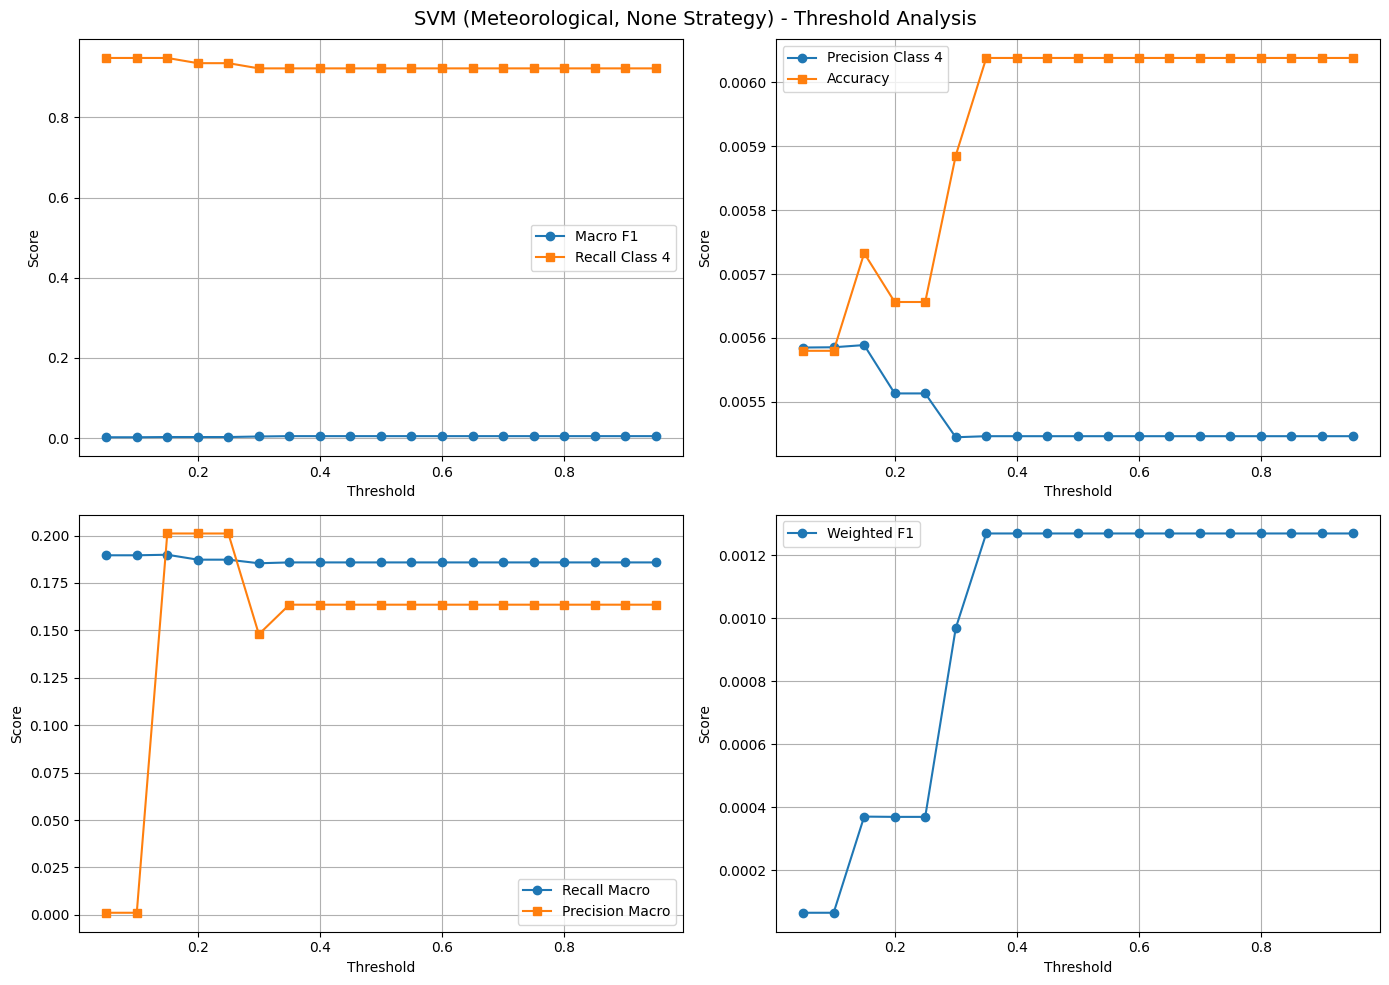

In [23]:
# Threshold analysis for SVM Meteorological (none strategy)
svm_met_none = next(m for m in best_models_met_svm if m[0] == "none")

# Convert SVM decision_function to probabilities

svm_met_decision = svm_met_none[1].decision_function(X_test_meteorological)
svm_met_proba = np.column_stack([expit(-svm_met_decision[:, i]) for i in range(5)])
svm_met_proba = svm_met_proba / svm_met_proba.sum(axis=1, keepdims=True)

svm_met_threshold = threshold_analysis_multiclass(y_test, svm_met_proba, np.arange(0.05, 1.0, 0.05))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SVM (Meteorological, None Strategy) - Threshold Analysis", fontsize=14)

axes[0, 0].plot(svm_met_threshold["threshold"], svm_met_threshold["f1_macro"], marker="o", label="Macro F1")
axes[0, 0].plot(svm_met_threshold["threshold"], svm_met_threshold["recall_class4"], marker="s", label="Recall Class 4")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(svm_met_threshold["threshold"], svm_met_threshold["precision_class4"], marker="o", label="Precision Class 4")
axes[0, 1].plot(svm_met_threshold["threshold"], svm_met_threshold["accuracy"], marker="s", label="Accuracy")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(svm_met_threshold["threshold"], svm_met_threshold["recall_macro"], marker="o", label="Recall Macro")
axes[1, 0].plot(svm_met_threshold["threshold"], svm_met_threshold["precision_macro"], marker="s", label="Precision Macro")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(svm_met_threshold["threshold"], svm_met_threshold["f1_weighted"], marker="o", label="Weighted F1")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Override best threshold as requested
best_threshold_svm_met = 0.15
print(f"SVM (Meteorological, None): Best threshold for Macro F1 set to {best_threshold_svm_met:.3f}")

# Make predictions using best threshold
class_4_proba = svm_met_proba[:, 4]
svm_met_preds_threshold = np.argmax(svm_met_proba, axis=1)
svm_met_preds_threshold = np.where(class_4_proba >= best_threshold_svm_met, 4, svm_met_preds_threshold)

classification_report_svm_met_weights = classification_report(
    y_test,
    svm_met_preds_threshold,
    output_dict=True
)

SVM (Meteorological, None): Best threshold for Macro F1 set to 0.150


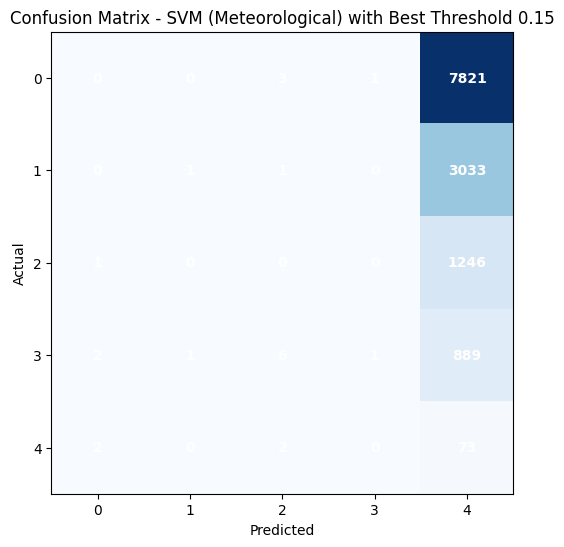

In [25]:
confusion_matrix_svm_met_weights = confusion_matrix(y_test, svm_met_preds_threshold)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_svm_met_weights, interpolation="nearest", cmap=plt.cm.Blues)

for i in range(confusion_matrix_svm_met_weights.shape[0]):
    for j in range(confusion_matrix_svm_met_weights.shape[1]):
        plt.text(j, i, str(confusion_matrix_svm_met_weights[i, j]),
                ha="center", va="center", color="white", fontweight="bold")

plt.title(f"Confusion Matrix - SVM (Meteorological) with Best Threshold {best_threshold_svm_met:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:

results.append({
    "model": "SVM",
    "features": "Meteorological",

    "precision_class_4": classification_report_svm_met_weights["4"]["precision"],
    "precision_class_3": classification_report_svm_met_weights["3"]["precision"],
    "precision_class_2": classification_report_svm_met_weights["2"]["precision"],
    "precision_class_1": classification_report_svm_met_weights["1"]["precision"],
    "precision_class_0": classification_report_svm_met_weights["0"]["precision"],
    "recall_class_4": classification_report_svm_met_weights["4"]["recall"],
    "recall_class_3": classification_report_svm_met_weights["3"]["recall"],
    "recall_class_2": classification_report_svm_met_weights["2"]["recall"],
    "recall_class_1": classification_report_svm_met_weights["1"]["recall"],
    "recall_class_0": classification_report_svm_met_weights["0"]["recall"],
    "f1_class_4": classification_report_svm_met_weights["4"]["f1-score"],
    "f1_class_3": classification_report_svm_met_weights["3"]["f1-score"],
    "f1_class_2": classification_report_svm_met_weights["2"]["f1-score"],
    "f1_class_1": classification_report_svm_met_weights["1"]["f1-score"],
    "f1_class_0": classification_report_svm_met_weights["0"]["f1-score"],
    "support_class_4": classification_report_svm_met_weights["4"]["support"],
    "support_class_3": classification_report_svm_met_weights["3"]["support"],
    "support_class_2": classification_report_svm_met_weights["2"]["support"],
    "support_class_1": classification_report_svm_met_weights["1"]["support"],
    "support_class_0": classification_report_svm_met_weights["0"]["support"],

    "macro_f1": classification_report_svm_met_weights["macro avg"]["f1-score"],
    "weighted_f1": classification_report_svm_met_weights["weighted avg"]["f1-score"],
    "precision_macro": classification_report_svm_met_weights["macro avg"]["precision"],
    "recall_macro": classification_report_svm_met_weights["macro avg"]["recall"],
    "best_threshold": best_threshold_svm_met,
    "best params": svm_met_none[2] 
})

#### Including air quality

#### XGBoost

In [27]:
scoring = {
    "recall_class4": recall_class4,
    "f1_macro": f1_macro_scorer
}

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

best_models_all_xgb = []

for name in weight_strategies:

    print(f"Training with weighting strategy: {name}")

    weights = make_weights(name, y_train)

    model = XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    )

    grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    refit="recall_class4",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

    grid_search.fit(
        X_train,
        y_train,
        sample_weight=weights
    )

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    xgboost_predictions_all = best_model.predict(X_test)

    recall4 = recall_score(y_test, xgboost_predictions_all, labels=[4], average="micro")
    recall4_train = recall_score(y_train, best_model.predict(X_train), labels=[4], average="micro")
    macrof1 = classification_report(y_test, xgboost_predictions_all, output_dict=True)["macro avg"]["f1-score"]
    recall = recall_score(y_test, xgboost_predictions_all, average="macro")
    precision = classification_report(y_test, xgboost_predictions_all, output_dict=True)["macro avg"]["precision"]

    best_models_all_xgb.append((name, best_model, best_params, recall4, recall4_train, macrof1, recall, precision, weights))

Training with weighting strategy: none
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Training with weighting strategy: balanced
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Training with weighting strategy: balanced_x2_class4
Fitting 3 folds for each of 12 candidates, totalling 36 fits


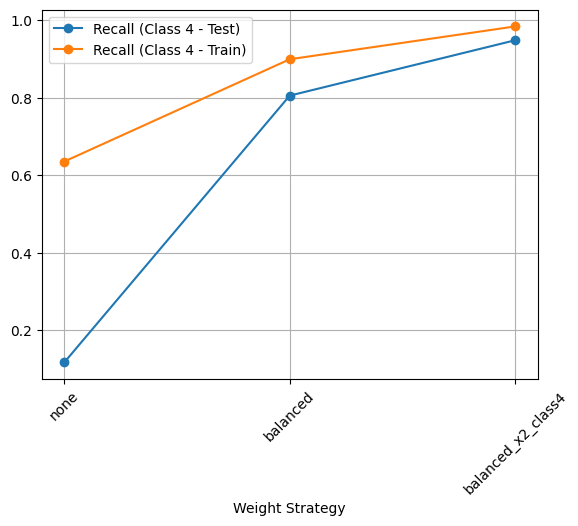

In [28]:
df_all_xgb = pd.DataFrame(best_models_all_xgb, columns=["weighting", "model", "best_params", "recall_class4", "recall_class4_train", "macro_f1", "recall", "precision", "weights"])

plt.plot(df_all_xgb["weighting"], df_all_xgb["recall_class4"], marker="o", label="Recall (Class 4 - Test)")
plt.plot(df_all_xgb["weighting"], df_all_xgb["recall_class4_train"], marker="o", label="Recall (Class 4 - Train)")
  
plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

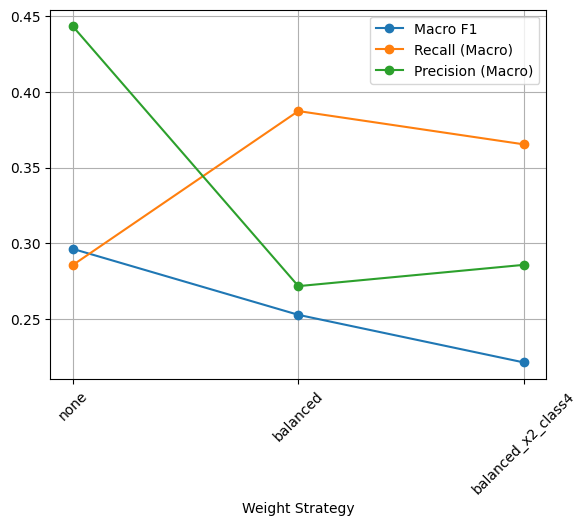

In [29]:
plt.plot(df_all_xgb["weighting"], df_all_xgb["macro_f1"], marker="o", label="Macro F1")
plt.plot(df_all_xgb["weighting"], df_all_xgb["recall"], marker="o", label="Recall (Macro)")
plt.plot(df_all_xgb["weighting"], df_all_xgb["precision"], marker="o", label="Precision (Macro)")  

plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

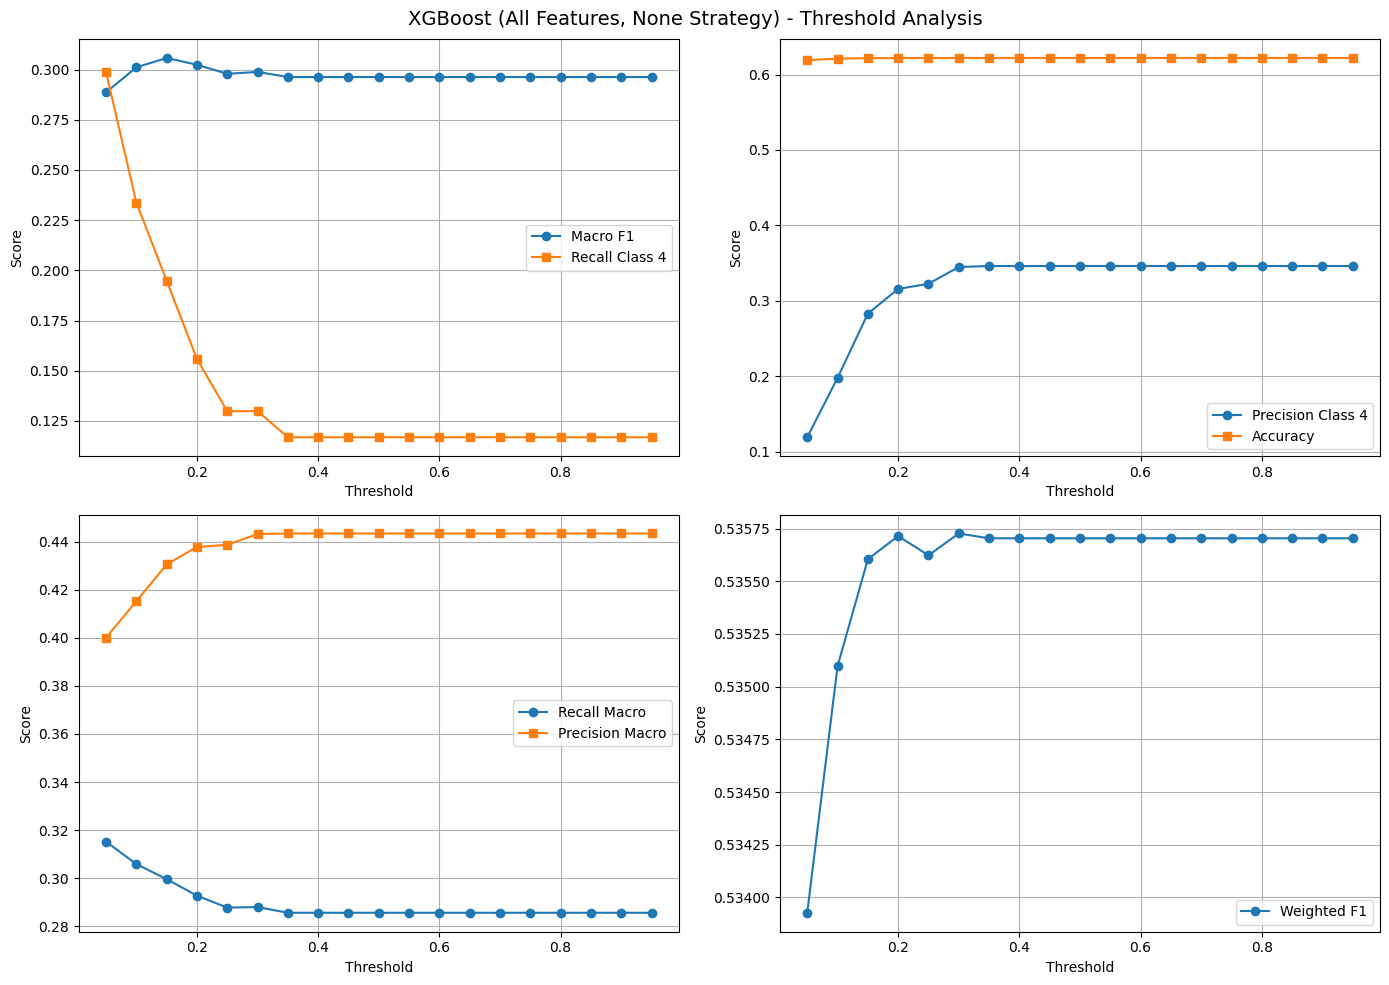

In [30]:
# Threshold analysis for XGBoost All Features (none strategy)
xgb_all_none = next(m for m in best_models_all_xgb if m[0] == "none")
xgb_all_proba = xgb_all_none[1].predict_proba(X_test)
xgb_all_threshold = threshold_analysis_multiclass(y_test, xgb_all_proba, np.arange(0.05, 1.0, 0.05))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("XGBoost (All Features, None Strategy) - Threshold Analysis", fontsize=14)

axes[0, 0].plot(xgb_all_threshold["threshold"], xgb_all_threshold["f1_macro"], marker="o", label="Macro F1")
axes[0, 0].plot(xgb_all_threshold["threshold"], xgb_all_threshold["recall_class4"], marker="s", label="Recall Class 4")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(xgb_all_threshold["threshold"], xgb_all_threshold["precision_class4"], marker="o", label="Precision Class 4")
axes[0, 1].plot(xgb_all_threshold["threshold"], xgb_all_threshold["accuracy"], marker="s", label="Accuracy")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(xgb_all_threshold["threshold"], xgb_all_threshold["recall_macro"], marker="o", label="Recall Macro")
axes[1, 0].plot(xgb_all_threshold["threshold"], xgb_all_threshold["precision_macro"], marker="s", label="Precision Macro")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(xgb_all_threshold["threshold"], xgb_all_threshold["f1_weighted"], marker="o", label="Weighted F1")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
# Override best threshold as requested
best_threshold_xgb_all = 0.15
print(f"XGBoost (All Features, None): Best threshold for Macro F1 set to {best_threshold_xgb_all:.3f}")

# Make predictions using best threshold
class_4_proba = xgb_all_proba[:, 4]
xgb_all_preds_threshold = np.argmax(xgb_all_proba, axis=1)
xgb_all_preds_threshold = np.where(class_4_proba >= best_threshold_xgb_all, 4, xgb_all_preds_threshold)

classification_report_xgboost_all_weights = classification_report(
    y_test,
    xgb_all_preds_threshold,
    output_dict=True
)

XGBoost (All Features, None): Best threshold for Macro F1 set to 0.150


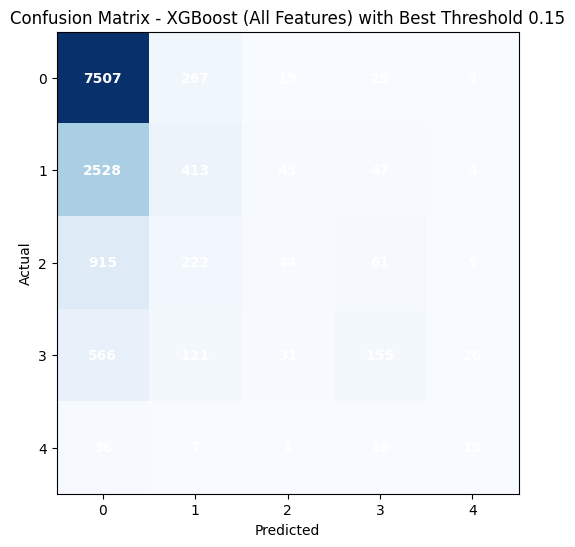

In [32]:
confusion_matrix_xgboost_all_weights = confusion_matrix(y_test, xgb_all_preds_threshold)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_xgboost_all_weights, interpolation="nearest", cmap=plt.cm.Blues)

for i in range(confusion_matrix_xgboost_all_weights.shape[0]):
    for j in range(confusion_matrix_xgboost_all_weights.shape[1]):
        plt.text(j, i, str(confusion_matrix_xgboost_all_weights[i, j]),
                ha="center", va="center", color="white", fontweight="bold")

plt.title(f"Confusion Matrix - XGBoost (All Features) with Best Threshold {best_threshold_xgb_all:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
results.append({
    "model": "XGBoost",
    "features": "All features",

    "precision_class_4": classification_report_xgboost_all_weights["4"]["precision"],
    "precision_class_3": classification_report_xgboost_all_weights["3"]["precision"],
    "precision_class_2": classification_report_xgboost_all_weights["2"]["precision"],
    "precision_class_1": classification_report_xgboost_all_weights["1"]["precision"],
    "precision_class_0": classification_report_xgboost_all_weights["0"]["precision"],
    "recall_class_4": classification_report_xgboost_all_weights["4"]["recall"],
    "recall_class_3": classification_report_xgboost_all_weights["3"]["recall"],
    "recall_class_2": classification_report_xgboost_all_weights["2"]["recall"],
    "recall_class_1": classification_report_xgboost_all_weights["1"]["recall"],
    "recall_class_0": classification_report_xgboost_all_weights["0"]["recall"],
    "f1_class_4": classification_report_xgboost_all_weights["4"]["f1-score"],
    "f1_class_3": classification_report_xgboost_all_weights["3"]["f1-score"],
    "f1_class_2": classification_report_xgboost_all_weights["2"]["f1-score"],
    "f1_class_1": classification_report_xgboost_all_weights["1"]["f1-score"],
    "f1_class_0": classification_report_xgboost_all_weights["0"]["f1-score"],
    "support_class_4": classification_report_xgboost_all_weights["4"]["support"],
    "support_class_3": classification_report_xgboost_all_weights["3"]["support"],
    "support_class_2": classification_report_xgboost_all_weights["2"]["support"],
    "support_class_1": classification_report_xgboost_all_weights["1"]["support"],
    "support_class_0": classification_report_xgboost_all_weights["0"]["support"],

    "macro_f1": classification_report_xgboost_all_weights["macro avg"]["f1-score"],
    "weighted_f1": classification_report_xgboost_all_weights["weighted avg"]["f1-score"],
    "precision_macro": classification_report_xgboost_all_weights["macro avg"]["precision"],
    "recall_macro": classification_report_xgboost_all_weights["macro avg"]["recall"],
    "best_threshold": best_threshold_xgb_all,
    "best params": xgb_all_none[2]
})

#### SVM

In [34]:
best_models_all_svm = []

for name in ["none"]:

    svm_model_all = SVC(
    kernel='rbf',
    max_iter=iterations,
    random_state=42
    )

    param_grid = {
    "C": [1, 10],
    "gamma": ["scale", 0.01]
    }

    weights = make_weights(name, y_train)

    grid_search = GridSearchCV(
        estimator=svm_model_all,
        param_grid=param_grid,
        scoring=recall_class4,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid_search.fit(
        X_train,
        y_train,
        **{"sample_weight": weights}
    )

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    preds = best_model.predict(X_test)


    recall4 = recall_score(y_test, preds, labels=[4], average="micro")
    recall4_train = recall_score(y_train, best_model.predict(X_train), labels=[4], average="micro")
    macrof1 = classification_report(y_test, preds, output_dict=True)["macro avg"]["f1-score"]
    recall = recall_score(y_test, preds, average="macro")
    precision = classification_report(y_test, preds, output_dict=True)["macro avg"]["precision"]

    best_models_all_svm.append((name, best_model, best_params, recall4, recall4_train, macrof1, recall, precision, weights))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\majak\Desktop\Uni\Thesis\Extreme-precipitation\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


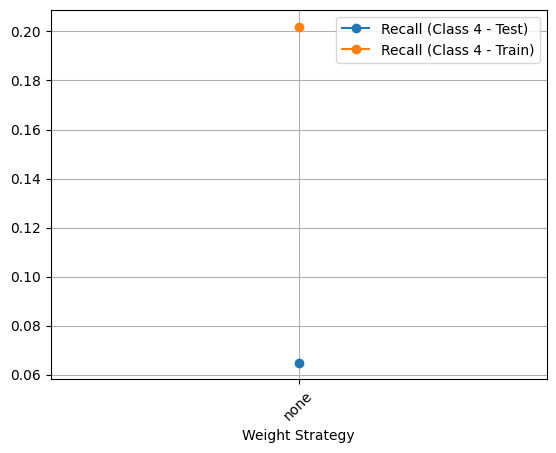

In [35]:
df_all_svm = pd.DataFrame(best_models_all_svm, columns=["weighting", "model", "best_params", "recall_class4", "recall_class4_train", "macro_f1", "recall", "precision", "weights"])

plt.plot(df_all_svm["weighting"], df_all_svm["recall_class4"], marker="o", label="Recall (Class 4 - Test)")
plt.plot(df_all_svm["weighting"], df_all_svm["recall_class4_train"], marker="o", label="Recall (Class 4 - Train)")
  
plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

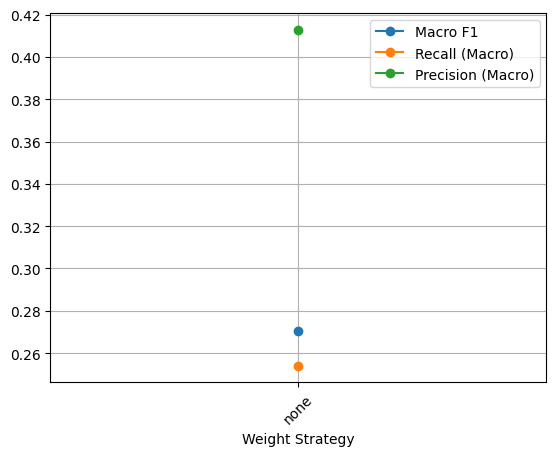

In [36]:
plt.plot(df_all_svm["weighting"], df_all_svm["macro_f1"], marker="o", label="Macro F1")
plt.plot(df_all_svm["weighting"], df_all_svm["recall"], marker="o", label="Recall (Macro)")
plt.plot(df_all_svm["weighting"], df_all_svm["precision"], marker="o", label="Precision (Macro)")  

plt.xlabel("Weight Strategy")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

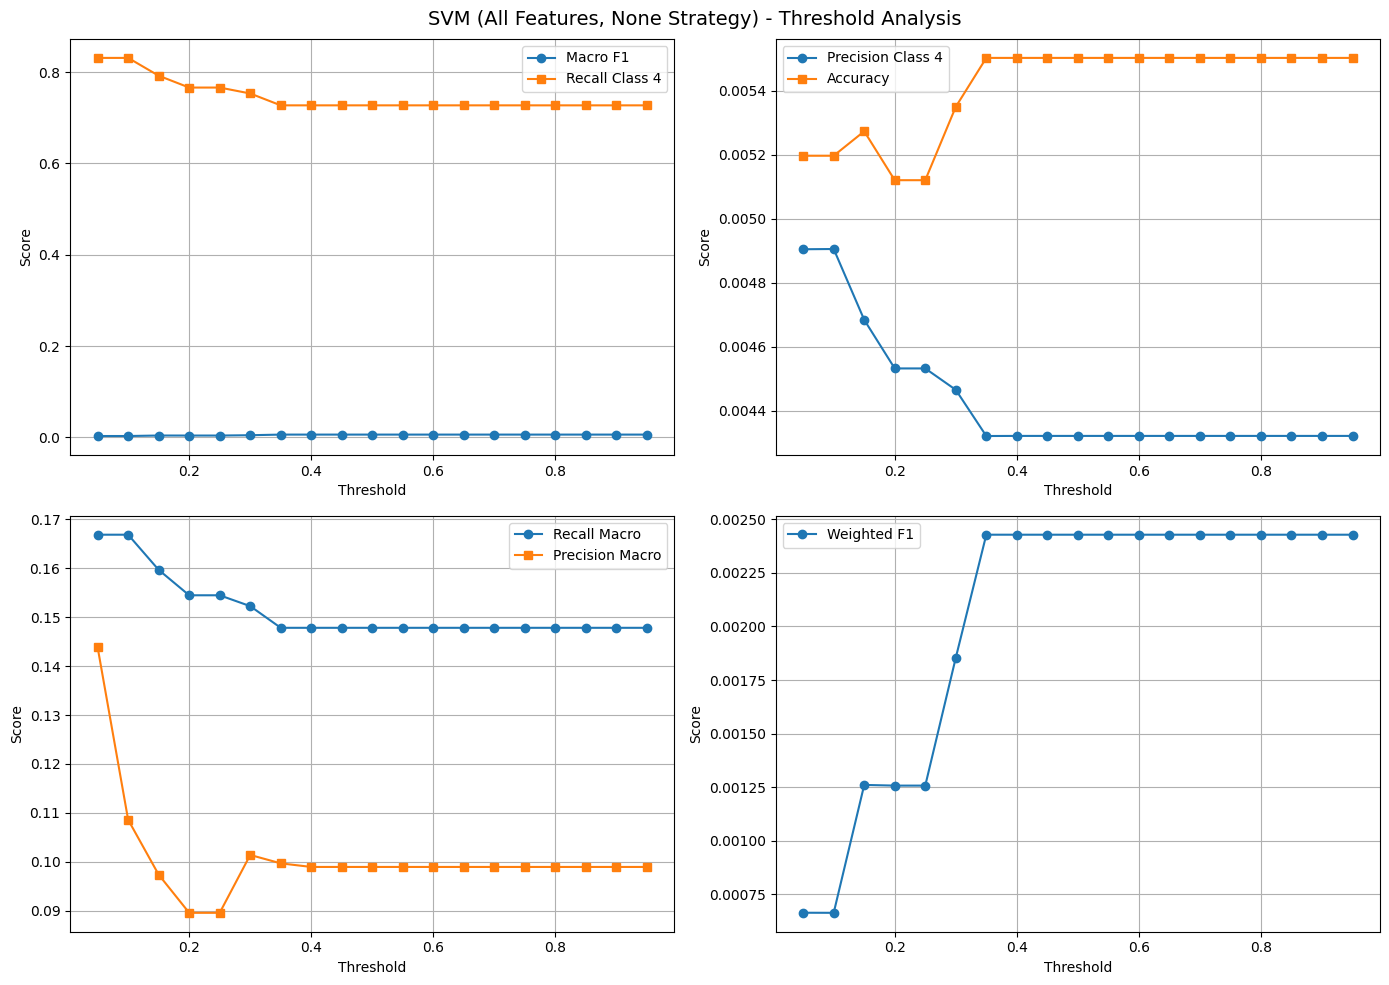

In [37]:
# Threshold analysis for SVM All Features (none strategy)
svm_all_none = next(m for m in best_models_all_svm if m[0] == "none")

# Convert SVM decision_function to probabilities
svm_all_decision = svm_all_none[1].decision_function(X_test)
svm_all_proba = np.column_stack([expit(-svm_all_decision[:, i]) for i in range(5)])
svm_all_proba = svm_all_proba / svm_all_proba.sum(axis=1, keepdims=True)

svm_all_threshold = threshold_analysis_multiclass(y_test, svm_all_proba, np.arange(0.05, 1.0, 0.05))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SVM (All Features, None Strategy) - Threshold Analysis", fontsize=14)

axes[0, 0].plot(svm_all_threshold["threshold"], svm_all_threshold["f1_macro"], marker="o", label="Macro F1")
axes[0, 0].plot(svm_all_threshold["threshold"], svm_all_threshold["recall_class4"], marker="s", label="Recall Class 4")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Score")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(svm_all_threshold["threshold"], svm_all_threshold["precision_class4"], marker="o", label="Precision Class 4")
axes[0, 1].plot(svm_all_threshold["threshold"], svm_all_threshold["accuracy"], marker="s", label="Accuracy")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Score")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(svm_all_threshold["threshold"], svm_all_threshold["recall_macro"], marker="o", label="Recall Macro")
axes[1, 0].plot(svm_all_threshold["threshold"], svm_all_threshold["precision_macro"], marker="s", label="Precision Macro")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(svm_all_threshold["threshold"], svm_all_threshold["f1_weighted"], marker="o", label="Weighted F1")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [38]:
# Override best threshold as requested
best_threshold_svm_all = 0.15
print(f"SVM (All Features, None): Best threshold for Macro F1 set to {best_threshold_svm_all:.4f}")

# Make predictions using best threshold
class_4_proba = svm_all_proba[:, 4]
svm_all_preds_threshold = np.argmax(svm_all_proba, axis=1)
svm_all_preds_threshold = np.where(class_4_proba >= best_threshold_svm_all, 4, svm_all_preds_threshold)

classification_report_svm_all_weights = classification_report(
    y_test,
    svm_all_preds_threshold,
    output_dict=True
)

SVM (All Features, None): Best threshold for Macro F1 set to 0.1500


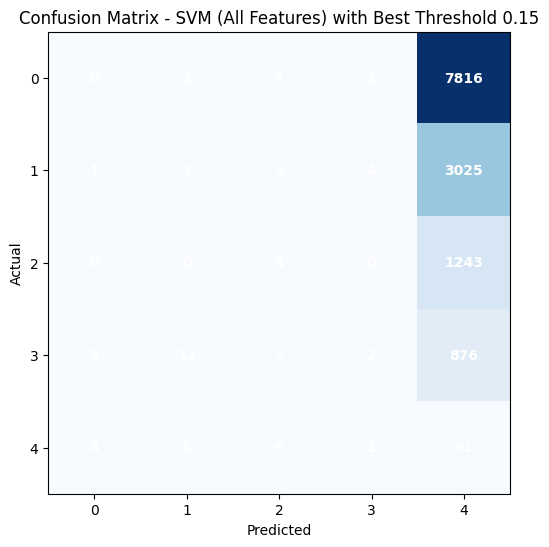

In [39]:
confusion_matrix_svm_all_weights = confusion_matrix(y_test, svm_all_preds_threshold)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_svm_all_weights, interpolation="nearest", cmap=plt.cm.Blues)

for i in range(confusion_matrix_svm_all_weights.shape[0]):
    for j in range(confusion_matrix_svm_all_weights.shape[1]):
        plt.text(j, i, str(confusion_matrix_svm_all_weights[i, j]),
                ha="center", va="center", color="white", fontweight="bold")

plt.title(f"Confusion Matrix - SVM (All Features) with Best Threshold {best_threshold_svm_all:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:

results.append({
    "model": "SVM",
    "features": "All features",

    "precision_class_4": classification_report_svm_all_weights["4"]["precision"],
    "precision_class_3": classification_report_svm_all_weights["3"]["precision"],
    "precision_class_2": classification_report_svm_all_weights["2"]["precision"],
    "precision_class_1": classification_report_svm_all_weights["1"]["precision"],
    "precision_class_0": classification_report_svm_all_weights["0"]["precision"],
    "recall_class_4": classification_report_svm_all_weights["4"]["recall"],
    "recall_class_3": classification_report_svm_all_weights["3"]["recall"],
    "recall_class_2": classification_report_svm_all_weights["2"]["recall"],
    "recall_class_1": classification_report_svm_all_weights["1"]["recall"],
    "recall_class_0": classification_report_svm_all_weights["0"]["recall"],
    "f1_class_4": classification_report_svm_all_weights["4"]["f1-score"],
    "f1_class_3": classification_report_svm_all_weights["3"]["f1-score"],
    "f1_class_2": classification_report_svm_all_weights["2"]["f1-score"],
    "f1_class_1": classification_report_svm_all_weights["1"]["f1-score"],
    "f1_class_0": classification_report_svm_all_weights["0"]["f1-score"],
    "support_class_4": classification_report_svm_all_weights["4"]["support"],
    "support_class_3": classification_report_svm_all_weights["3"]["support"],
    "support_class_2": classification_report_svm_all_weights["2"]["support"],
    "support_class_1": classification_report_svm_all_weights["1"]["support"],
    "support_class_0": classification_report_svm_all_weights["0"]["support"],

    "macro_f1": classification_report_svm_all_weights["macro avg"]["f1-score"],
    "weighted_f1": classification_report_svm_all_weights["weighted avg"]["f1-score"],
    "precision_macro": classification_report_svm_all_weights["macro avg"]["precision"],
    "recall_macro": classification_report_svm_all_weights["macro avg"]["recall"],
    "best_threshold": best_threshold_svm_all,
    "best params": svm_all_none[2]
    })

### Analysis of results

In [41]:
# Create DataFrame and save results to LaTeX
results_df = pd.DataFrame(results)
results_df.to_latex("data/model_results.tex", index=False)

In [42]:
results_df.head(10)

,model,features,precision_class_4,precision_class_3,precision_class_2,precision_class_1,precision_class_0,recall_class_4,recall_class_3,recall_class_2,...,support_class_3,support_class_2,support_class_1,support_class_0,macro_f1,weighted_f1,precision_macro,recall_macro,best_threshold,best params
0,XGBoost,Meteorological,0.194444,0.400000,0.285714,0.294821,0.618093,0.090909,0.082314,0.008019,...,899.0,1247.0,3035.0,7825.0,0.223168,0.483256,0.358615,0.240711,0.15,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
1,SVM,Meteorological,0.005589,0.500000,0.000000,0.500000,0.000000,0.948052,0.001112,0.000000,...,899.0,1247.0,3035.0,7825.0,0.002798,0.000371,0.201118,0.189899,0.15,"{'C': 10, 'gamma': 'scale'}"
2,XGBoost,All features,0.283019,0.500000,0.318841,0.400971,0.649844,0.194805,0.172414,0.035285,...,899.0,1247.0,3035.0,7825.0,0.305750,0.535604,0.430535,0.299589,0.15,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
3,SVM,All features,0.004685,0.222222,0.160000,0.100000,0.000000,0.792208,0.002225,0.003208,...,899.0,1247.0,3035.0,7825.0,0.004264,0.001261,0.097381,0.159660,0.15,"{'C': 10, 'gamma': 'scale'}"


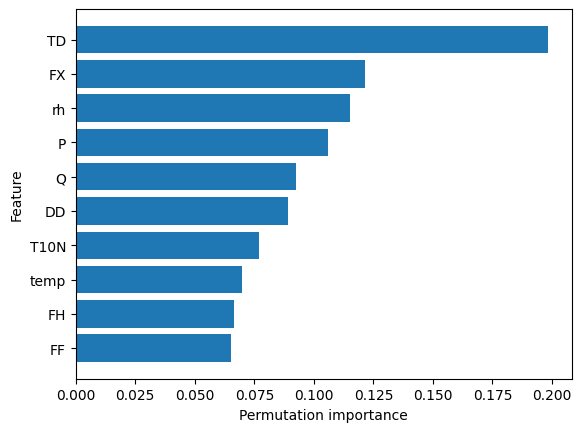

In [43]:
# Get feature importance
xgboost_importance_met = xgb_met_none[1].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": meteorological_features,
    "importance": xgboost_importance_met
})

# Sort
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure()

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Permutation importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

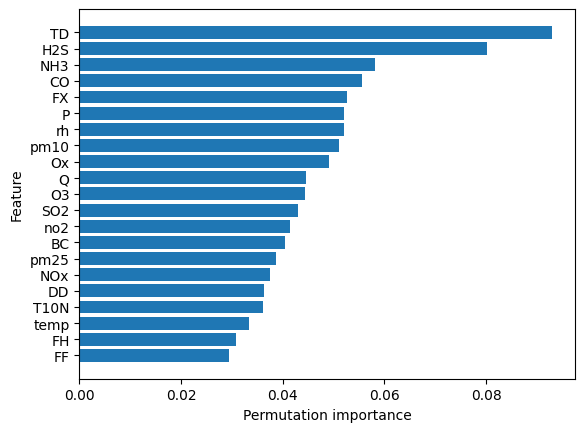

In [44]:
# Get feature importance
xgboost_importance_all = xgb_all_none[1].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgboost_importance_all
})

# Sort
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure()

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Permutation importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

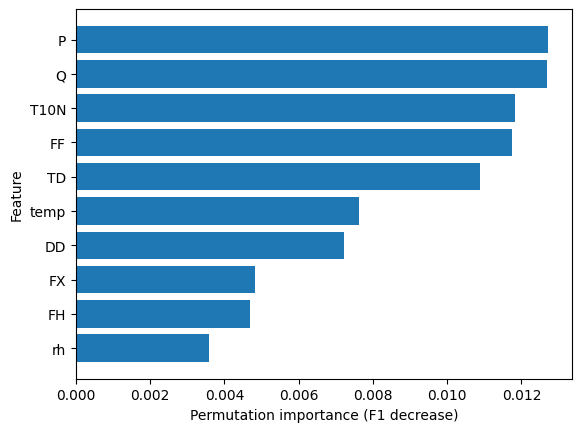

In [45]:
result = permutation_importance(
    svm_met_none[1],          # trained SVM
    X_test_meteorological,
    y_test,
    n_repeats=2,
    random_state=42,
    scoring="f1_macro", 
    n_jobs=-1
)

importance = result.importances_mean
std = result.importances_std

feature_importance = pd.DataFrame({
    "feature": X[meteorological_features].columns,
    "importance": importance,
    "std": std
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure()

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Permutation importance (F1 decrease)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

c:\Users\majak\Desktop\Uni\Thesis\Extreme-precipitation\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


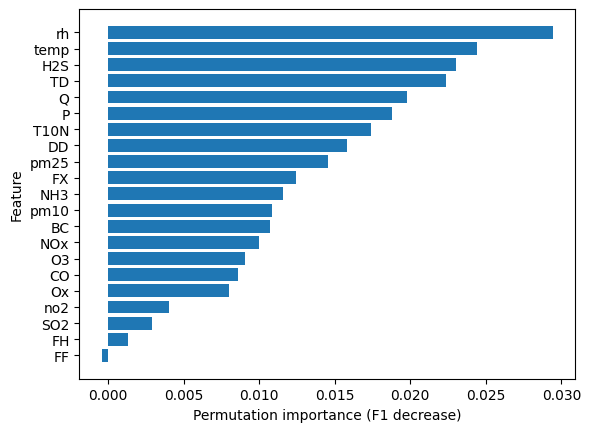

In [46]:
result = permutation_importance(
    svm_all_none[1],          # trained SVM
    X_test,
    y_test,
    n_repeats=2,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importance = result.importances_mean
std = result.importances_std

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance,
    "std": std
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

plt.figure()

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Permutation importance (F1 decrease)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

#### Statistical difference in meterological vs aerosol models

In [47]:
# Use threshold-optimized predictions from all 4 models
preds_xgb_aero = xgb_all_preds_threshold

preds_xgb_met = xgb_met_preds_threshold

preds_svm_met = svm_met_preds_threshold

preds_svm_aero = svm_all_preds_threshold

In [48]:
differences_xgb = []

n_bootstraps = 1000

for _ in range(n_bootstraps):

    indices = np.random.choice(
        len(y_test),
        len(y_test),
        replace=True
    )

    y_bs = y_test.iloc[indices]

    preds_met_bs = preds_xgb_met[indices]
    preds_aero_bs = preds_xgb_aero[indices]

    f1_met = f1_score(y_bs, preds_met_bs, average="macro")
    f1_aero = f1_score(y_bs, preds_aero_bs, average="macro")

    differences_xgb.append(f1_aero - f1_met)

lower_xgb = np.percentile(differences_xgb, 2.5)
upper_xgb = np.percentile(differences_xgb, 97.5)

print("XGBoost ΔMacroF1 95% CI:")
print(lower_xgb, upper_xgb)

print("Mean difference:")
print(np.mean(differences_xgb))

XGBoost ΔMacroF1 95% CI:
0.05730340016209537 0.10710386743952618
Mean difference:
0.08253436835617953


In [49]:
differences_svm = []

for _ in range(n_bootstraps):

    indices = np.random.choice(
        len(y_test),
        len(y_test),
        replace=True
    )

    y_bs = y_test.iloc[indices]

    preds_met_bs = preds_svm_met[indices]
    preds_aero_bs = preds_svm_aero[indices]

    f1_met = f1_score(y_bs, preds_met_bs, average="macro")
    f1_aero = f1_score(y_bs, preds_aero_bs, average="macro")

    differences_svm.append(f1_aero - f1_met)

lower_svm = np.percentile(differences_svm, 2.5)
upper_svm = np.percentile(differences_svm, 97.5)

print("SVM ΔMacroF1 95% CI:")
print(lower_svm, upper_svm)

print("Mean difference:")
print(np.mean(differences_svm))

SVM ΔMacroF1 95% CI:
-0.00036357577567098793 0.00336175967381385
Mean difference:
0.0014758578288857958
